In [ ]:
# Created DataFrame

In [1]:
from selenium import webdriver
import pandas as pd
import time
import random

In [3]:
driver = webdriver.Chrome()
driver.get('https://nflplayoffpass.com/super-bowl-winners/')

data = []

for i in range(1,60):
    winners = driver.find_element('xpath', f'//*[@id="post-3005"]/div[1]/div/figure[3]/table/tbody/tr[{i}]/td[3]').text
    opposition = driver.find_element('xpath', f'//*[@id="post-3005"]/div[1]/div/figure[3]/table/tbody/tr[{i}]/td[4]').text
    year = driver.find_element('xpath', f'//*[@id="post-3005"]/div[1]/div/figure[3]/table/tbody/tr[{i}]/td[2]').text
    
    data.append([year, winners, opposition])

In [5]:
df = pd.DataFrame(data, columns = ["Year", "Team 1", "Team 2"])

In [7]:
df

,Year,Team 1,Team 2
0,2025,Philadelphia Eagles,Kansas City Chiefs
1,2024,Kansas City Chiefs,San Francisco 49ers
2,2023,Kansas City Chiefs,Philadelphia Eagles
3,2022,Los Angeles Rams,Cincinnati Bengals
4,2021,Tampa Bay Buccaneers,Kansas City Chiefs
5,2020,Kansas City Chiefs,San Francisco 49ers
6,2019,New England Patriots,Los Angeles Rams
7,2018,Philadelphia Eagles,New England Patriots
8,2017,New England Patriots,Atlanta Falcons
9,2016,Denver Broncos,Carolina Panthers


In [9]:
ticket_price = [6304,9400,9915,7654,6173,3789,2812,2799,2605,2605,2111,2500,1339,1306,1344,
                1138,1168,1052,853,871,776,799,679,557,458,475,488,420,426,559,328,295,303,
                268,275,242,204,213,75,169,140,145,101,105,113,95,108,118,84,89,95,79,87,90,
                93,98,83,83,87]

In [11]:
df["Ticket Price"] = ticket_price
df

,Year,Team 1,Team 2,Ticket Price
0,2025,Philadelphia Eagles,Kansas City Chiefs,6304
1,2024,Kansas City Chiefs,San Francisco 49ers,9400
2,2023,Kansas City Chiefs,Philadelphia Eagles,9915
3,2022,Los Angeles Rams,Cincinnati Bengals,7654
4,2021,Tampa Bay Buccaneers,Kansas City Chiefs,6173
5,2020,Kansas City Chiefs,San Francisco 49ers,3789
6,2019,New England Patriots,Los Angeles Rams,2812
7,2018,Philadelphia Eagles,New England Patriots,2799
8,2017,New England Patriots,Atlanta Falcons,2605
9,2016,Denver Broncos,Carolina Panthers,2605


In [13]:
df['Year'] = df['Year'].astype(int)

In [15]:
df2 = pd.read_csv('Data_400_data.csv')
df2 = df2.iloc[:, :-2]
df2 = df2.sort_values(by='Year', ascending=False)
df2['Year'] = df2['Year'].astype(int)

In [17]:
df2.head()

,Year,Super_Bowl,Stadium,Indoor,City,State
58,2025,LIX,Caesars Superdome,1,New Orleans,Louisiana
57,2024,LVIII,Allegiant Stadium,1,Paradise,Nevada
56,2023,LVII,State Farm Stadium,1,Glendale,Arizona
55,2022,LVI,SoFi Stadium,1,Inglewood,California
54,2021,LV,Raymond James Stadium,0,Tampa,Florida


In [19]:
df.dtypes

Year             int32
Team 1          object
Team 2          object
Ticket Price     int64
dtype: object

In [21]:
df2.dtypes

Year           int32
Super_Bowl    object
Stadium       object
Indoor         int64
City          object
State         object
dtype: object

In [23]:
combined_df = pd.merge(df, df2, on='Year', how='inner')

In [25]:
combined_df.head(10)

,Year,Team 1,Team 2,Ticket Price,Super_Bowl,Stadium,Indoor,City,State
0,2025,Philadelphia Eagles,Kansas City Chiefs,6304,LIX,Caesars Superdome,1,New Orleans,Louisiana
1,2024,Kansas City Chiefs,San Francisco 49ers,9400,LVIII,Allegiant Stadium,1,Paradise,Nevada
2,2023,Kansas City Chiefs,Philadelphia Eagles,9915,LVII,State Farm Stadium,1,Glendale,Arizona
3,2022,Los Angeles Rams,Cincinnati Bengals,7654,LVI,SoFi Stadium,1,Inglewood,California
4,2021,Tampa Bay Buccaneers,Kansas City Chiefs,6173,LV,Raymond James Stadium,0,Tampa,Florida
5,2020,Kansas City Chiefs,San Francisco 49ers,3789,LIV,Hard Rock Stadium,0,Miami,Florida
6,2019,New England Patriots,Los Angeles Rams,2812,LIII,Mercedes-Benz Stadium,1,Atlanta,Georgia
7,2018,Philadelphia Eagles,New England Patriots,2799,LII,U.S. Bank Stadium,1,Minneapolis,Minnesota
8,2017,New England Patriots,Atlanta Falcons,2605,LI,NRG Stadium,1,Houston,Texas
9,2016,Denver Broncos,Carolina Panthers,2605,L,Levi's Stadium,0,Santa Clara,California


In [27]:
df3 = pd.read_csv("SuperBowl Halftime Performances.csv")
df3 = df3.iloc[:, [0, 3]]
df3 = df3.sort_values(by='Year', ascending=False)

In [29]:
df3

,Year,Type of Halftime Performance
58,2025,3
57,2024,3
56,2023,3
55,2022,2
54,2021,3
53,2020,2
52,2019,2
51,2018,3
50,2017,3
49,2016,3


In [31]:
combined_df = pd.merge(combined_df, df3, on='Year', how='inner')

In [33]:
combined_df

,Year,Team 1,Team 2,Ticket Price,Super_Bowl,Stadium,Indoor,City,State,Type of Halftime Performance
0,2025,Philadelphia Eagles,Kansas City Chiefs,6304,LIX,Caesars Superdome,1,New Orleans,Louisiana,3
1,2024,Kansas City Chiefs,San Francisco 49ers,9400,LVIII,Allegiant Stadium,1,Paradise,Nevada,3
2,2023,Kansas City Chiefs,Philadelphia Eagles,9915,LVII,State Farm Stadium,1,Glendale,Arizona,3
3,2022,Los Angeles Rams,Cincinnati Bengals,7654,LVI,SoFi Stadium,1,Inglewood,California,2
4,2021,Tampa Bay Buccaneers,Kansas City Chiefs,6173,LV,Raymond James Stadium,0,Tampa,Florida,3
5,2020,Kansas City Chiefs,San Francisco 49ers,3789,LIV,Hard Rock Stadium,0,Miami,Florida,2
6,2019,New England Patriots,Los Angeles Rams,2812,LIII,Mercedes-Benz Stadium,1,Atlanta,Georgia,2
7,2018,Philadelphia Eagles,New England Patriots,2799,LII,U.S. Bank Stadium,1,Minneapolis,Minnesota,3
8,2017,New England Patriots,Atlanta Falcons,2605,LI,NRG Stadium,1,Houston,Texas,3
9,2016,Denver Broncos,Carolina Panthers,2605,L,Levi's Stadium,0,Santa Clara,California,3


In [35]:
df4 = pd.read_csv("SuperBowl Attendance.csv")
df4 = df4.sort_values(by='Year', ascending=False)

In [37]:
combined_df = pd.merge(combined_df, df4, on= "Year", how= 'inner')

In [39]:
combined_df

,Year,Team 1,Team 2,Ticket Price,Super_Bowl,Stadium,Indoor,City,State,Type of Halftime Performance,Attendance
0,2025,Philadelphia Eagles,Kansas City Chiefs,6304,LIX,Caesars Superdome,1,New Orleans,Louisiana,3,65719
1,2024,Kansas City Chiefs,San Francisco 49ers,9400,LVIII,Allegiant Stadium,1,Paradise,Nevada,3,61629
2,2023,Kansas City Chiefs,Philadelphia Eagles,9915,LVII,State Farm Stadium,1,Glendale,Arizona,3,67827
3,2022,Los Angeles Rams,Cincinnati Bengals,7654,LVI,SoFi Stadium,1,Inglewood,California,2,70048
4,2021,Tampa Bay Buccaneers,Kansas City Chiefs,6173,LV,Raymond James Stadium,0,Tampa,Florida,3,24835
5,2020,Kansas City Chiefs,San Francisco 49ers,3789,LIV,Hard Rock Stadium,0,Miami,Florida,2,62417
6,2019,New England Patriots,Los Angeles Rams,2812,LIII,Mercedes-Benz Stadium,1,Atlanta,Georgia,2,70081
7,2018,Philadelphia Eagles,New England Patriots,2799,LII,U.S. Bank Stadium,1,Minneapolis,Minnesota,3,67612
8,2017,New England Patriots,Atlanta Falcons,2605,LI,NRG Stadium,1,Houston,Texas,3,70807
9,2016,Denver Broncos,Carolina Panthers,2605,L,Levi's Stadium,0,Santa Clara,California,3,71088


In [41]:
df5 = pd.read_csv("Data 400 RS Win % + Year.csv")
df5 = df5.sort_values('Year', ascending=False).reset_index(drop=True)

In [43]:
df5

,Winner RS Win %,Loser RS Win %,Year
0,0.824,0.882,2025
1,0.647,0.706,2024
2,0.824,0.824,2023
3,0.706,0.588,2022
4,0.688,0.875,2021
5,0.750,0.813,2020
6,0.688,0.813,2019
7,0.813,0.813,2018
8,0.875,0.688,2017
9,0.750,0.938,2016


In [45]:
combined_df = pd.merge(combined_df, df5, on= "Year", how= 'inner')

In [47]:
combined_df

,Year,Team 1,Team 2,Ticket Price,Super_Bowl,Stadium,Indoor,City,State,Type of Halftime Performance,Attendance,Winner RS Win %,Loser RS Win %
0,2025,Philadelphia Eagles,Kansas City Chiefs,6304,LIX,Caesars Superdome,1,New Orleans,Louisiana,3,65719,0.824,0.882
1,2024,Kansas City Chiefs,San Francisco 49ers,9400,LVIII,Allegiant Stadium,1,Paradise,Nevada,3,61629,0.647,0.706
2,2023,Kansas City Chiefs,Philadelphia Eagles,9915,LVII,State Farm Stadium,1,Glendale,Arizona,3,67827,0.824,0.824
3,2022,Los Angeles Rams,Cincinnati Bengals,7654,LVI,SoFi Stadium,1,Inglewood,California,2,70048,0.706,0.588
4,2021,Tampa Bay Buccaneers,Kansas City Chiefs,6173,LV,Raymond James Stadium,0,Tampa,Florida,3,24835,0.688,0.875
5,2020,Kansas City Chiefs,San Francisco 49ers,3789,LIV,Hard Rock Stadium,0,Miami,Florida,2,62417,0.750,0.813
6,2019,New England Patriots,Los Angeles Rams,2812,LIII,Mercedes-Benz Stadium,1,Atlanta,Georgia,2,70081,0.688,0.813
7,2018,Philadelphia Eagles,New England Patriots,2799,LII,U.S. Bank Stadium,1,Minneapolis,Minnesota,3,67612,0.813,0.813
8,2017,New England Patriots,Atlanta Falcons,2605,LI,NRG Stadium,1,Houston,Texas,3,70807,0.875,0.688
9,2016,Denver Broncos,Carolina Panthers,2605,L,Levi's Stadium,0,Santa Clara,California,3,71088,0.750,0.938


In [49]:
df6 = pd.read_csv("Stadium Capacity.csv")

In [51]:
df6_2 = df6.drop("Stadium", axis=1)

In [53]:
df6_2.head()

,Year,Capacity
0,2025,73208
1,2024,65000
2,2023,63400
3,2022,70240
4,2021,69218


In [55]:
combined_df

,Year,Team 1,Team 2,Ticket Price,Super_Bowl,Stadium,Indoor,City,State,Type of Halftime Performance,Attendance,Winner RS Win %,Loser RS Win %
0,2025,Philadelphia Eagles,Kansas City Chiefs,6304,LIX,Caesars Superdome,1,New Orleans,Louisiana,3,65719,0.824,0.882
1,2024,Kansas City Chiefs,San Francisco 49ers,9400,LVIII,Allegiant Stadium,1,Paradise,Nevada,3,61629,0.647,0.706
2,2023,Kansas City Chiefs,Philadelphia Eagles,9915,LVII,State Farm Stadium,1,Glendale,Arizona,3,67827,0.824,0.824
3,2022,Los Angeles Rams,Cincinnati Bengals,7654,LVI,SoFi Stadium,1,Inglewood,California,2,70048,0.706,0.588
4,2021,Tampa Bay Buccaneers,Kansas City Chiefs,6173,LV,Raymond James Stadium,0,Tampa,Florida,3,24835,0.688,0.875
5,2020,Kansas City Chiefs,San Francisco 49ers,3789,LIV,Hard Rock Stadium,0,Miami,Florida,2,62417,0.750,0.813
6,2019,New England Patriots,Los Angeles Rams,2812,LIII,Mercedes-Benz Stadium,1,Atlanta,Georgia,2,70081,0.688,0.813
7,2018,Philadelphia Eagles,New England Patriots,2799,LII,U.S. Bank Stadium,1,Minneapolis,Minnesota,3,67612,0.813,0.813
8,2017,New England Patriots,Atlanta Falcons,2605,LI,NRG Stadium,1,Houston,Texas,3,70807,0.875,0.688
9,2016,Denver Broncos,Carolina Panthers,2605,L,Levi's Stadium,0,Santa Clara,California,3,71088,0.750,0.938


In [ ]:
# Exploratory Data Analysis

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

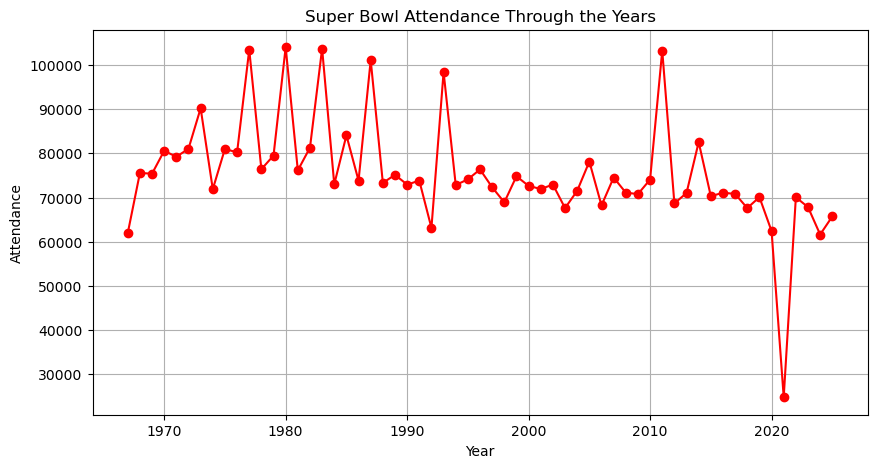

In [60]:
# Super Bowl Attendance
plt.figure(figsize=(10,5))
plt.plot(combined_df['Year'], combined_df['Attendance'], marker='o', color = 'red')
plt.title('Super Bowl Attendance Through the Years')
plt.xlabel('Year')
plt.ylabel('Attendance')
plt.grid(True)
plt.show()

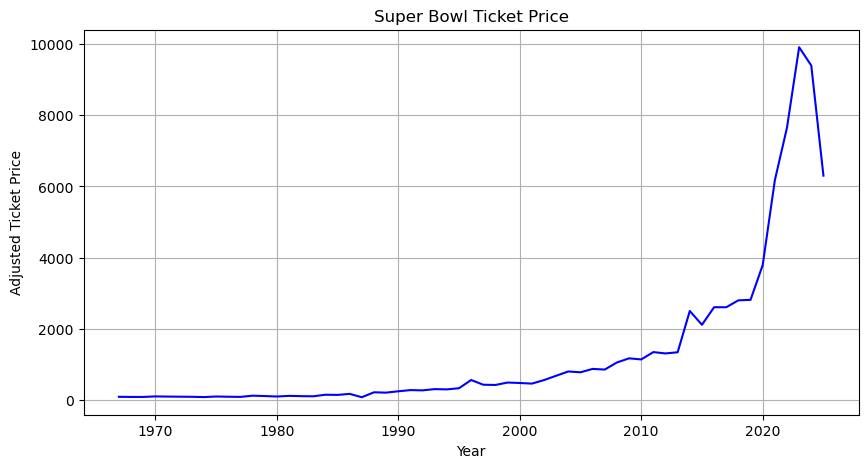

In [63]:
#Super Bowl Ticket Price
plt.figure(figsize=(10,5))
plt.plot(combined_df['Year'], combined_df['Ticket Price'], color = 'blue')
plt.title('Super Bowl Ticket Price')
plt.xlabel('Year')
plt.ylabel('Adjusted Ticket Price')
plt.grid(True)
plt.show()

In [65]:
city = combined_df.groupby('City')['Attendance'].mean().sort_values(ascending=False)

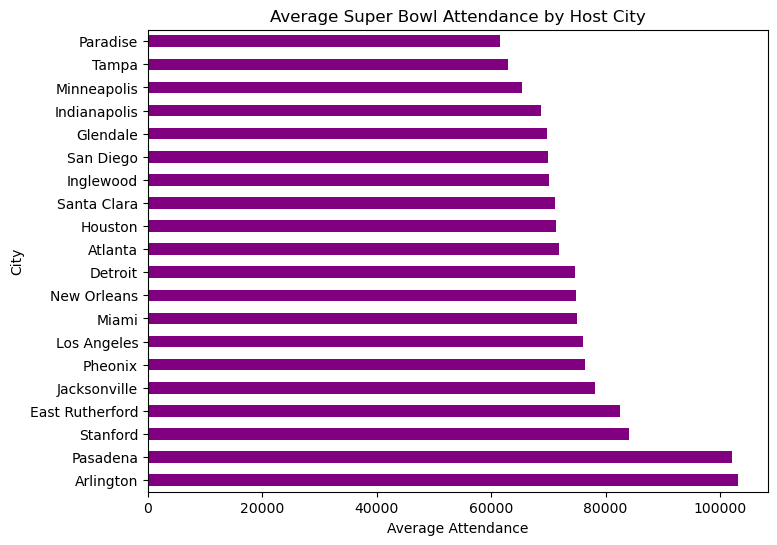

In [67]:
# Host City Super Bowl Attendance
city.plot(kind='barh', figsize=(8,6), color = 'purple')
plt.title('Average Super Bowl Attendance by Host City')
plt.xlabel('Average Attendance')
plt.ylabel('City')
plt.show()

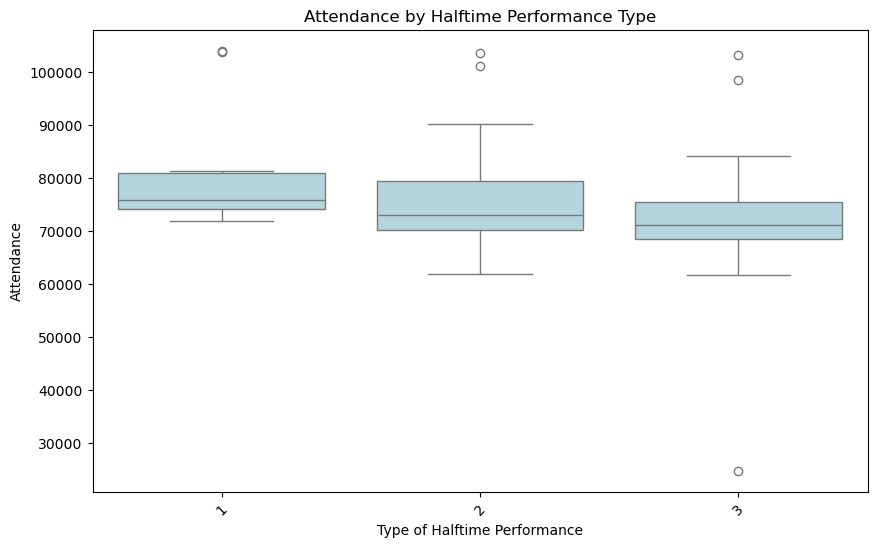

In [69]:
# Halftime Performance Types
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_df, x="Type of Halftime Performance", y="Attendance", color = "lightblue")

plt.title("Attendance by Halftime Performance Type")
plt.xlabel("Type of Halftime Performance")
plt.ylabel("Attendance")
plt.xticks(rotation=45)
plt.show()

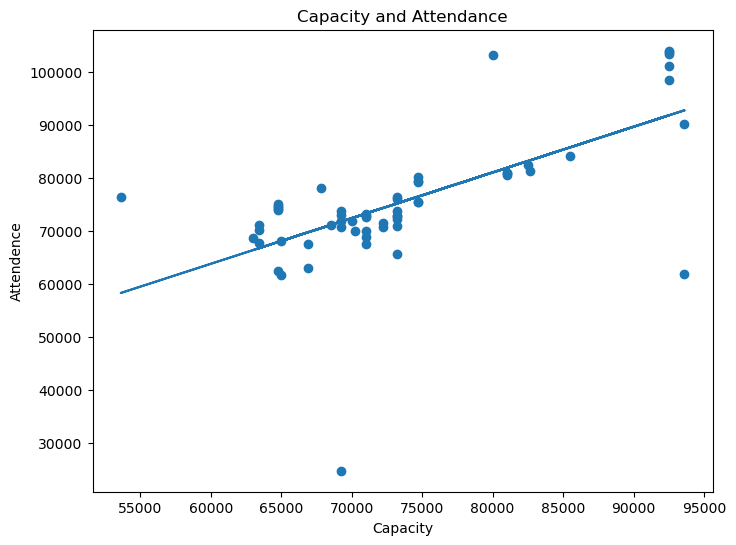

In [144]:
# Capacity vs Attendance
import matplotlib.pyplot as plt
import pandas as pd

# Select variables
x = combined_df['Capacity']
y = combined_df['Attendance']

# Convert to numeric and remove missing values
data = pd.concat([x, y], axis=1).apply(pd.to_numeric, errors='coerce').dropna()
x = data['Capacity']
y = data['Attendance']

# Compute Pearson correlation
corr = x.corr(y)

# Plot
import numpy as np

m, b = np.polyfit(x, y, 1)
plt.figure(figsize=(8, 6))
plt.scatter(x, y)
plt.plot(x, m*x + b)
plt.xlabel('Capacity')
plt.ylabel('Attendence')
plt.title(f'Capacity and Attendance')
plt.show()





In [73]:
df_model = combined_df.rename(columns={
    "Winner RS Win %": "Winner_RS_WinPct",
    "Loser RS Win %": "Loser_RS_WinPct",
    "Ticket Price": "TicketPrice",          # if you have this
    "Type of Halftime Performance": "Type_of_Halftime_Performance",
    "Indoor ": "Indoor"
})

In [79]:
combined_df = df_model

In [81]:
combined_df

,Year,Team 1,Team 2,TicketPrice,Super_Bowl,Stadium,Indoor,City,State,Type_of_Halftime_Performance,Attendance,Winner_RS_WinPct,Loser_RS_WinPct
0,2025,Philadelphia Eagles,Kansas City Chiefs,6304,LIX,Caesars Superdome,1,New Orleans,Louisiana,3,65719,0.824,0.882
1,2024,Kansas City Chiefs,San Francisco 49ers,9400,LVIII,Allegiant Stadium,1,Paradise,Nevada,3,61629,0.647,0.706
2,2023,Kansas City Chiefs,Philadelphia Eagles,9915,LVII,State Farm Stadium,1,Glendale,Arizona,3,67827,0.824,0.824
3,2022,Los Angeles Rams,Cincinnati Bengals,7654,LVI,SoFi Stadium,1,Inglewood,California,2,70048,0.706,0.588
4,2021,Tampa Bay Buccaneers,Kansas City Chiefs,6173,LV,Raymond James Stadium,0,Tampa,Florida,3,24835,0.688,0.875
5,2020,Kansas City Chiefs,San Francisco 49ers,3789,LIV,Hard Rock Stadium,0,Miami,Florida,2,62417,0.750,0.813
6,2019,New England Patriots,Los Angeles Rams,2812,LIII,Mercedes-Benz Stadium,1,Atlanta,Georgia,2,70081,0.688,0.813
7,2018,Philadelphia Eagles,New England Patriots,2799,LII,U.S. Bank Stadium,1,Minneapolis,Minnesota,3,67612,0.813,0.813
8,2017,New England Patriots,Atlanta Falcons,2605,LI,NRG Stadium,1,Houston,Texas,3,70807,0.875,0.688
9,2016,Denver Broncos,Carolina Panthers,2605,L,Levi's Stadium,0,Santa Clara,California,3,71088,0.750,0.938


In [95]:
combined_df.dtypes

Year                              int32
Team 1                           object
Team 2                           object
TicketPrice                       int64
Super_Bowl                       object
Stadium                          object
Indoor                            int64
City                             object
State                            object
Type_of_Halftime_Performance      int64
Attendance                        int64
Winner_RS_WinPct                float64
Loser_RS_WinPct                 float64
Capacity                          int64
dtype: object

In [87]:
df_model.columns
len(df_model)

59

In [89]:
capacities = [
    73208, 65000, 63400, 70240, 69218, 64767, 71000, 66860, 72220, 68500, 63400, 82500, 73208, 63000, 80000, 
    64767, 69218, 63400, 64767, 65000, 67814, 72220, 71000, 73208, 69218, 71000, 64767, 71000, 73208, 53599,
    64767, 71000, 92542, 66860, 69218, 73208, 64767, 71000, 92542, 73208, 85500, 69218, 92542, 82666, 73208, 
    92542, 74712, 73208, 92542, 74712, 80985, 70000, 93607, 80985, 74712, 80985, 74712, 74712, 93607
]  # length must equal len(df_model)

df_model["Capacity"] = capacities

In [91]:
df_model

,Year,Team 1,Team 2,TicketPrice,Super_Bowl,Stadium,Indoor,City,State,Type_of_Halftime_Performance,Attendance,Winner_RS_WinPct,Loser_RS_WinPct,Capacity
0,2025,Philadelphia Eagles,Kansas City Chiefs,6304,LIX,Caesars Superdome,1,New Orleans,Louisiana,3,65719,0.824,0.882,73208
1,2024,Kansas City Chiefs,San Francisco 49ers,9400,LVIII,Allegiant Stadium,1,Paradise,Nevada,3,61629,0.647,0.706,65000
2,2023,Kansas City Chiefs,Philadelphia Eagles,9915,LVII,State Farm Stadium,1,Glendale,Arizona,3,67827,0.824,0.824,63400
3,2022,Los Angeles Rams,Cincinnati Bengals,7654,LVI,SoFi Stadium,1,Inglewood,California,2,70048,0.706,0.588,70240
4,2021,Tampa Bay Buccaneers,Kansas City Chiefs,6173,LV,Raymond James Stadium,0,Tampa,Florida,3,24835,0.688,0.875,69218
5,2020,Kansas City Chiefs,San Francisco 49ers,3789,LIV,Hard Rock Stadium,0,Miami,Florida,2,62417,0.750,0.813,64767
6,2019,New England Patriots,Los Angeles Rams,2812,LIII,Mercedes-Benz Stadium,1,Atlanta,Georgia,2,70081,0.688,0.813,71000
7,2018,Philadelphia Eagles,New England Patriots,2799,LII,U.S. Bank Stadium,1,Minneapolis,Minnesota,3,67612,0.813,0.813,66860
8,2017,New England Patriots,Atlanta Falcons,2605,LI,NRG Stadium,1,Houston,Texas,3,70807,0.875,0.688,72220
9,2016,Denver Broncos,Carolina Panthers,2605,L,Levi's Stadium,0,Santa Clara,California,3,71088,0.750,0.938,68500


In [97]:
import statsmodels.formula.api as smf
import numpy as np


df_model_2= df_model[df_model["Year"] != 2021].copy()

model = smf.ols(
    'Attendance ~ Capacity + Winner_RS_WinPct + Loser_RS_WinPct '
    '+ Indoor + C(Type_of_Halftime_Performance)',
    data=df_model_2
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             Attendance   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     12.47
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.35e-08
Time:                        13:07:58   Log-Likelihood:                -592.37
No. Observations:                  58   AIC:                             1199.
Df Residuals:                      51   BIC:                             1213.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [99]:
# Added TicketPrice for Model to Evaluate

df_model_2 = df_model[df_model["Year"] != 2021].copy()



model = smf.ols(
    'Attendance ~ Capacity + Winner_RS_WinPct + Loser_RS_WinPct '
    '+ Indoor + C(Type_of_Halftime_Performance) + TicketPrice',
    data=df_model_2
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Attendance   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     11.59
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.21e-08
Time:                        13:08:17   Log-Likelihood:                -590.59
No. Observations:                  58   AIC:                             1197.
Df Residuals:                      50   BIC:                             1214.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [101]:
#68500 #levis capacity # outdoor #halftime category 3

In [174]:
win_wp_2026  = df_model_2["Winner_RS_WinPct"].mean()
lose_wp_2026 = df_model_2["Loser_RS_WinPct"].mean()
ticket_2026 = df_model_2["TicketPrice"].mean()

In [186]:
print(win_wp_2026)
print(lose_wp_2026)
print(ticket_2026)

0.7861206896551723
0.776206896551724
1232.1896551724137


In [176]:
capacity_2026 = 68500        
indoor_2026   = 0            
halftime_2026 = 3            

win_wp_2026  = df_model_2["Winner_RS_WinPct"].mean()
lose_wp_2026 = df_model_2["Loser_RS_WinPct"].mean()
ticket_2026  = df_model_2["TicketPrice"].mean()

new_2026 = pd.DataFrame({
    "Type_of_Halftime_Performance": [halftime_2026],
    "Capacity": [capacity_2026],
    "Winner_RS_WinPct": [win_wp_2026],
    "Loser_RS_WinPct": [lose_wp_2026],
    "Indoor": [indoor_2026],
    "TicketPrice": [ticket_2026]
})

In [178]:
pred_2026 = model.predict(new_2026)
print("Predicted 2026 attendance:", round(pred_2026.iloc[0]))

Predicted 2026 attendance: 76079


In [121]:
pred_2026_full = model.get_prediction(new_2026)
print(pred_2026_full.summary_frame(alpha=0.05))

          mean      mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  76079.28798  1845.723638   72372.042949   79786.533012  61751.449221   

   obs_ci_upper  
0   90407.12674  


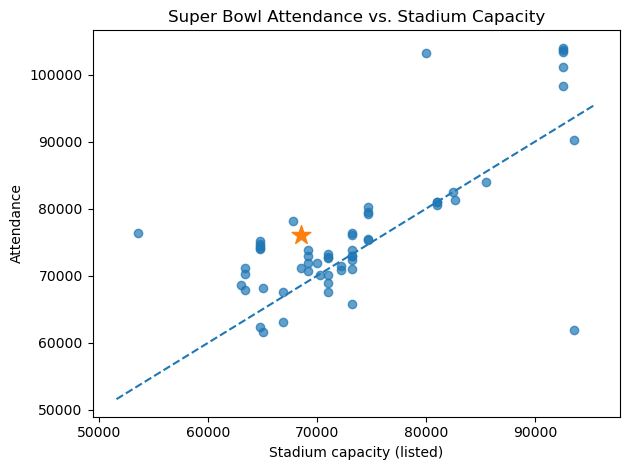

In [123]:
import matplotlib.pyplot as plt

df_plot = df_model_2.copy()   # your data without 2021

# base scatter
plt.scatter(df_plot["Capacity"], df_plot["Attendance"], alpha=0.7)

# 45-degree line (attendance = capacity)
min_cap = df_plot["Capacity"].min() - 2000
max_cap = df_plot["Capacity"].max() + 2000
plt.plot([min_cap, max_cap], [min_cap, max_cap], linestyle='--')

# add 2026 prediction
pred_2026 = model.predict(new_2026).iloc[0]
cap_2026  = new_2026["Capacity"].iloc[0]
plt.scatter([cap_2026], [pred_2026], marker='*', s=200)

plt.xlabel("Stadium capacity (listed)")
plt.ylabel("Attendance")
plt.title("Super Bowl Attendance vs. Stadium Capacity")
plt.tight_layout()

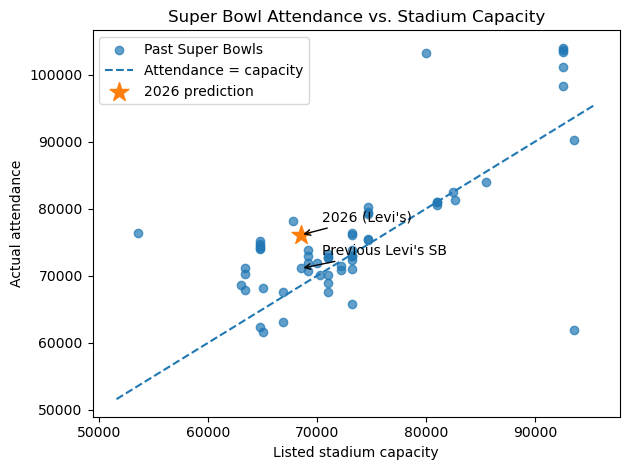

In [125]:
import matplotlib.pyplot as plt



fig, ax = plt.subplots()


ax.scatter(
    df_plot["Capacity"],
    df_plot["Attendance"],
    alpha=0.7,
    label="Past Super Bowls"
)


min_cap = df_plot["Capacity"].min() - 2000
max_cap = df_plot["Capacity"].max() + 2000
ax.plot(
    [min_cap, max_cap],
    [min_cap, max_cap],
    linestyle="--",
    label="Attendance = capacity"
)


ax.scatter(
    [cap_2026],
    [pred_2026],
    marker="*",
    s=200,
    label="2026 prediction"
)


ax.set_xlabel("Listed stadium capacity")
ax.set_ylabel("Actual attendance")
ax.set_title("Super Bowl Attendance vs. Stadium Capacity")


ax.legend()


ax.annotate(
    "2026 (Levi's)",
    xy=(cap_2026, pred_2026),
    xytext=(cap_2026 + 2000, pred_2026 + 2000),  # move text a bit
    arrowprops=dict(arrowstyle="->", lw=1)
)


levis_mask = df_plot["Stadium"].str.contains("Levi", case=False, na=False)
if levis_mask.any():
    levis_row = df_plot[levis_mask].iloc[0]
    ax.annotate(
        "Previous Levi's SB",
        xy=(levis_row["Capacity"], levis_row["Attendance"]),
        xytext=(levis_row["Capacity"] + 2000, levis_row["Attendance"] + 2000),
        arrowprops=dict(arrowstyle="->", lw=1)
    )

plt.tight_layout()
plt.show()


In [ ]:
# Notes

# clear positive relationship between capacity and attendance Bigger listed stadium
# capacity is generally associated with higher actual attendance (points rise as you move
# right)

# Many games are played at or near listed capacity. A big chunk of Super Bowls cluster
# close to the dashed "attendance = capacity" line, especially in the 65k-80k capacity
# range, indicating sell-outs or near sell-outs

# Some games fall noticeably below capacity. There are a few points well nder the line
# (including a large-capacity stadium with relatively low attendance), showing that not
# every Super Bowl fully uses the stadium's potential

# Some games exceed listed capacity. A handful of dots sit above the dashed-line, meaning
# realized attendance is higher than the stardard listed capacity -- likely due to the
# temporary seating, standing room sections, or alternate configurations for major events

# 2026 prediction vs Levi's history. The orange star (2026 at Levi's) sits above the
# equality line but in the same general region as other over-capacity games and close to
# Levi's previous Super Bow, suggesting the prediction is high but still in line with
# historical patterns

In [ ]:
# Regular Season Win Percentage Analysis

# Average- to check whether matchups between stronger teams (higher average win %)
# draw more fans

# Gap- how far apart were the teams in the standings/ how lopsided the matchup was

In [127]:
# Regular Season Win Percentage Analysis
avg_win = (df_model["Winner_RS_WinPct"] + df_model["Loser_RS_WinPct"]) / 2
gap_win = (df_model["Winner_RS_WinPct"] - df_model["Loser_RS_WinPct"]).abs()

summary_table = pd.DataFrame({
    "Year": df_model["Year"],             
    "Avg_RS_WinPct": avg_win,
    "RS_WinPct_Gap": gap_win,              
    "Attendance": df_model["Attendance"]
})

summary_table.head()

,Year,Avg_RS_WinPct,RS_WinPct_Gap,Attendance
0,2025,0.8530,0.058,65719
1,2024,0.6765,0.059,61629
2,2023,0.8240,0.000,67827
3,2022,0.6470,0.118,70048
4,2021,0.7815,0.187,24835


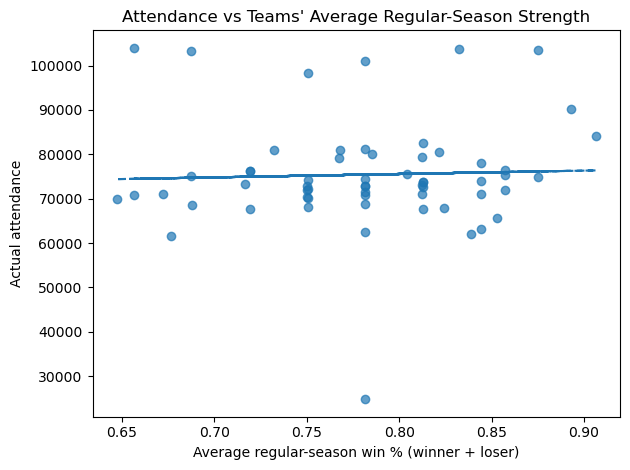

Correlation: 0.03838224360562766


In [129]:
import matplotlib.pyplot as plt
import numpy as np

x = summary_table["Avg_RS_WinPct"]
y = summary_table["Attendance"]

plt.scatter(x, y, alpha=0.7)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, linestyle="--")

plt.xlabel("Average regular-season win % (winner + loser)")
plt.ylabel("Actual attendance")
plt.title("Attendance vs Teams' Average Regular-Season Strength")
plt.tight_layout()
plt.show()

print("Correlation:", x.corr(y))

In [ ]:
# correlations - 0.04 --> basically 0

# the blue line is almost flat

# for any given average win % attendance is spread all over the place: mid-60Ks, 70ks,
# even 100K+

#Super Bowls with two really strong teams (high average win %) do not have systematically
# higher attendance than games with more average teams

# quality, on average, doesn't really move how many people show up --> matches regression
# results

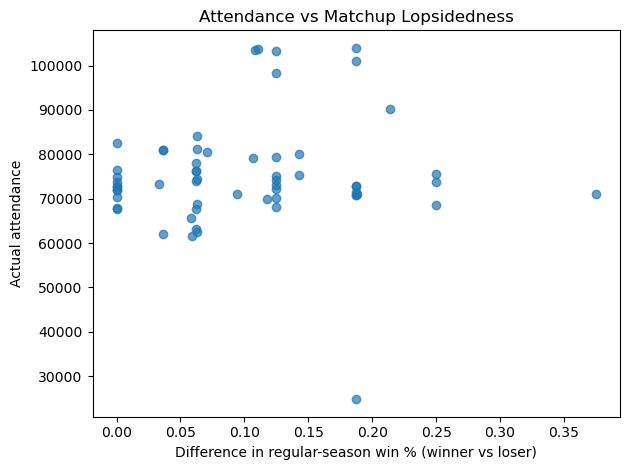

Correlation: 0.06688183001448701


In [131]:
x = summary_table["RS_WinPct_Gap"]
y = summary_table["Attendance"]

plt.scatter(x, y, alpha=0.7)

plt.xlabel("Difference in regular-season win % (winner vs loser)")
plt.ylabel("Actual attendance")
plt.title("Attendance vs Matchup Lopsidedness")
plt.tight_layout()
plt.show()

print("Correlation:", x.corr(y))

In [152]:
std_dev = combined_df['TicketPrice'].std()
mean = combined_df['TicketPrice'].mean()
print(mean)
print(std_dev)

1315.9322033898304
2236.168851687056


In [154]:
combined_df

,Year,Team 1,Team 2,TicketPrice,Super_Bowl,Stadium,Indoor,City,State,Type_of_Halftime_Performance,Attendance,Winner_RS_WinPct,Loser_RS_WinPct,Capacity
0,2025,Philadelphia Eagles,Kansas City Chiefs,6304,LIX,Caesars Superdome,1,New Orleans,Louisiana,3,65719,0.824,0.882,73208
1,2024,Kansas City Chiefs,San Francisco 49ers,9400,LVIII,Allegiant Stadium,1,Paradise,Nevada,3,61629,0.647,0.706,65000
2,2023,Kansas City Chiefs,Philadelphia Eagles,9915,LVII,State Farm Stadium,1,Glendale,Arizona,3,67827,0.824,0.824,63400
3,2022,Los Angeles Rams,Cincinnati Bengals,7654,LVI,SoFi Stadium,1,Inglewood,California,2,70048,0.706,0.588,70240
4,2021,Tampa Bay Buccaneers,Kansas City Chiefs,6173,LV,Raymond James Stadium,0,Tampa,Florida,3,24835,0.688,0.875,69218
5,2020,Kansas City Chiefs,San Francisco 49ers,3789,LIV,Hard Rock Stadium,0,Miami,Florida,2,62417,0.750,0.813,64767
6,2019,New England Patriots,Los Angeles Rams,2812,LIII,Mercedes-Benz Stadium,1,Atlanta,Georgia,2,70081,0.688,0.813,71000
7,2018,Philadelphia Eagles,New England Patriots,2799,LII,U.S. Bank Stadium,1,Minneapolis,Minnesota,3,67612,0.813,0.813,66860
8,2017,New England Patriots,Atlanta Falcons,2605,LI,NRG Stadium,1,Houston,Texas,3,70807,0.875,0.688,72220
9,2016,Denver Broncos,Carolina Panthers,2605,L,Levi's Stadium,0,Santa Clara,California,3,71088,0.750,0.938,68500


In [164]:
import pandas as pd

# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows (if needed)
pd.set_option('display.max_rows', None)

# Expand the width of columns
pd.set_option('display.max_colwidth', None)

# Set the width of the display in characters
pd.set_option('display.width', 100)  # Adjust as needed


In [172]:
combined_df

,Year,Team 1,Team 2,TicketPrice,Super_Bowl,Stadium,Indoor,City,State,Type_of_Halftime_Performance,Attendance,Winner_RS_WinPct,Loser_RS_WinPct,Capacity
0,2025,Philadelphia Eagles,Kansas City Chiefs,6304,LIX,Caesars Superdome,1,New Orleans,Louisiana,3,65719,0.824,0.882,73208
1,2024,Kansas City Chiefs,San Francisco 49ers,9400,LVIII,Allegiant Stadium,1,Paradise,Nevada,3,61629,0.647,0.706,65000
2,2023,Kansas City Chiefs,Philadelphia Eagles,9915,LVII,State Farm Stadium,1,Glendale,Arizona,3,67827,0.824,0.824,63400
3,2022,Los Angeles Rams,Cincinnati Bengals,7654,LVI,SoFi Stadium,1,Inglewood,California,2,70048,0.706,0.588,70240
4,2021,Tampa Bay Buccaneers,Kansas City Chiefs,6173,LV,Raymond James Stadium,0,Tampa,Florida,3,24835,0.688,0.875,69218
5,2020,Kansas City Chiefs,San Francisco 49ers,3789,LIV,Hard Rock Stadium,0,Miami,Florida,2,62417,0.750,0.813,64767
6,2019,New England Patriots,Los Angeles Rams,2812,LIII,Mercedes-Benz Stadium,1,Atlanta,Georgia,2,70081,0.688,0.813,71000
7,2018,Philadelphia Eagles,New England Patriots,2799,LII,U.S. Bank Stadium,1,Minneapolis,Minnesota,3,67612,0.813,0.813,66860
8,2017,New England Patriots,Atlanta Falcons,2605,LI,NRG Stadium,1,Houston,Texas,3,70807,0.875,0.688,72220
9,2016,Denver Broncos,Carolina Panthers,2605,L,Levi's Stadium,0,Santa Clara,California,3,71088,0.750,0.938,68500
